# Notebook 4 - Summary & Cross-Architecture Analysis

This notebook is the **presentational wrap-up**. It does no training — instead it:

1. Instantiates every model so we can compare **parameter counts and architectures**.
2. Displays the pre-generated **evaluation report** (`evaluation_report.txt`) and chatbot **loss curves** PNG from a previous `main.py` run.
3. Summarizes the cross-architecture findings across Task 1 (text generation) and Task 2 (chatbots).

> Run [Task 1 data](task1_text_generation/notebooks/01_data.ipynb) and [Task 2 data](task2_chatbot/notebooks/01_data.ipynb), [`02_text_generation.ipynb`](task1_text_generation/notebooks/02_text_generation.ipynb), and [`../../task2_chatbot/notebooks/02_chatbots.ipynb`](03_chatbots.ipynb) first for the live trained models. This notebook is meant to be rendered quickly during a presentation.

## Setup

In [1]:
import os
import sys
from IPython.display import Image, display

PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/arderd/nlp-from-scratch


## Part 1 - Architecture comparison

Instantiate each model (without training) to report parameter counts side-by-side. This is the quickest way to see how expensive each architecture is.

In [2]:
import torch
from tabulate import tabulate

from task1_text_generation.models.rnn_model import RNNModel
from task1_text_generation.models.lstm_model import LSTMModel
from task2_chatbot.models.lstm_chatbot import LSTMChatbot
from task2_chatbot.models.transformer_chatbot import TransformerChatbot

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Approximate vocabulary sizes (actual values depend on corpus/QA set)
CHAR_VOCAB = 80      # typical char set size for our corpus
WORD_VOCAB = 1500    # typical word vocab from ~12k-word corpus
QA_VOCAB   = 1800    # typical word vocab from QA pairs

rows = []

# Text generation models (neural ones; Markov has no params)
m = RNNModel(vocab_size=CHAR_VOCAB, embed_dim=64, hidden_dim=128, num_layers=2)
rows.append(["Char RNN",   "text-gen", f"{CHAR_VOCAB}",  f"{count_params(m):,}"])

m = RNNModel(vocab_size=WORD_VOCAB, embed_dim=64, hidden_dim=128, num_layers=2)
rows.append(["Word RNN",   "text-gen", f"{WORD_VOCAB}",  f"{count_params(m):,}"])

m = LSTMModel(vocab_size=CHAR_VOCAB, embed_dim=64, hidden_dim=128, num_layers=2)
rows.append(["Char LSTM",  "text-gen", f"{CHAR_VOCAB}",  f"{count_params(m):,}"])

m = LSTMModel(vocab_size=WORD_VOCAB, embed_dim=64, hidden_dim=128, num_layers=2)
rows.append(["Word LSTM",  "text-gen", f"{WORD_VOCAB}",  f"{count_params(m):,}"])

# Chatbot models
m = LSTMChatbot(vocab_size=QA_VOCAB, embed_dim=128, hidden_dim=256, num_layers=2)
rows.append(["LSTM seq2seq (Bahdanau)", "chatbot", f"{QA_VOCAB}", f"{count_params(m):,}"])

m = TransformerChatbot(
    vocab_size=QA_VOCAB, d_model=128, num_heads=4, d_ff=512,
    num_encoder_layers=3, num_decoder_layers=3,
)
rows.append(["Transformer (3+3 layers)", "chatbot", f"{QA_VOCAB}", f"{count_params(m):,}"])

print(tabulate(rows,
               headers=["Model", "Task", "Vocab", "Parameters"],
               tablefmt="grid"))
print("\nMarkov chains are count-based (no learned parameters); their 'state table' "
      "size grows with the corpus rather than being a fixed parameter count.")

+--------------------------+----------+---------+--------------+
| Model                    | Task     |   Vocab |   Parameters |
+==========================+==========+=========+==============+
| Char RNN                 | text-gen |      80 |       73,296 |
+--------------------------+----------+---------+--------------+
| Word RNN                 | text-gen |    1500 |      347,356 |
+--------------------------+----------+---------+--------------+
| Char LSTM                | text-gen |      80 |      246,864 |
+--------------------------+----------+---------+--------------+
| Word LSTM                | text-gen |    1500 |      520,924 |
+--------------------------+----------+---------+--------------+
| LSTM seq2seq (Bahdanau)  | chatbot  |    1800 |    6,348,552 |
+--------------------------+----------+---------+--------------+
| Transformer (3+3 layers) | chatbot  |    1800 |    2,081,544 |
+--------------------------+----------+---------+--------------+

Markov chains are count-

### Architecture sketches

```
Text generation (char or word):
    tokens → Embedding → [RNN | LSTM] × 2 → Dropout → Linear → vocab logits

LSTM seq2seq chatbot:
    question → BiLSTM encoder → [h, c]
                                   ↓
                       Bahdanau attention over encoder outputs
                                   ↓
                       LSTM decoder (step by step) → token probs

Transformer chatbot:
    question → embed + pos → [self-attn + FFN] × 3  (encoder)
                                                  ↓
    <sos>... → embed + pos → [masked self-attn + cross-attn + FFN] × 3  (decoder)
                                                  ↓
                                              token probs
```

## Part 2 - Evaluation report

The full text report produced by the pipeline (`evaluation_report.txt`) contains training-performance tables and 10-prompt comparison tables for every model. We display it inline here.

If the report is missing, run `python main.py` from the project root to regenerate it, or run notebooks 02 and 03 end-to-end.

In [3]:
report_path = os.path.join(PROJECT_ROOT, "evaluation_report.txt")

if os.path.exists(report_path):
    with open(report_path, "r", encoding="utf-8") as f:
        report = f.read()
    print(report)
else:
    print(f"(No evaluation_report.txt found at {report_path}. "
          "Run `python main.py` from the project root to generate it.)")

NLP PROJECT - EVALUATION REPORT

PART 1: TEXT GENERATION MODELS

TEXT GENERATION MODELS - TRAINING PERFORMANCE COMPARISON
+-------------------+-----------------+----------------+--------------+
| Model             | Training Time   | Memory Usage   | Final Loss   |
+===================+=================+================+==============+
| Char Markov Chain | 0.15s           | 2.5 MB         | N/A          |
+-------------------+-----------------+----------------+--------------+
| Word Markov Chain | 0.01s           | 2.0 MB         | N/A          |
+-------------------+-----------------+----------------+--------------+
| Char RNN          | 101.61s         | 828.1 MB       | 0.6689       |
+-------------------+-----------------+----------------+--------------+
| Word RNN          | 18.36s          | 2.0 MB         | 0.7746       |
+-------------------+-----------------+----------------+--------------+
| Char LSTM         | 107.64s         | 2.5 MB         | 0.2943       |
+-------------

## Part 3 - Chatbot loss curves (from last pipeline run)

Static PNG written by `task2_chatbot/evaluate.py` (called by `main.py` or notebook 03).

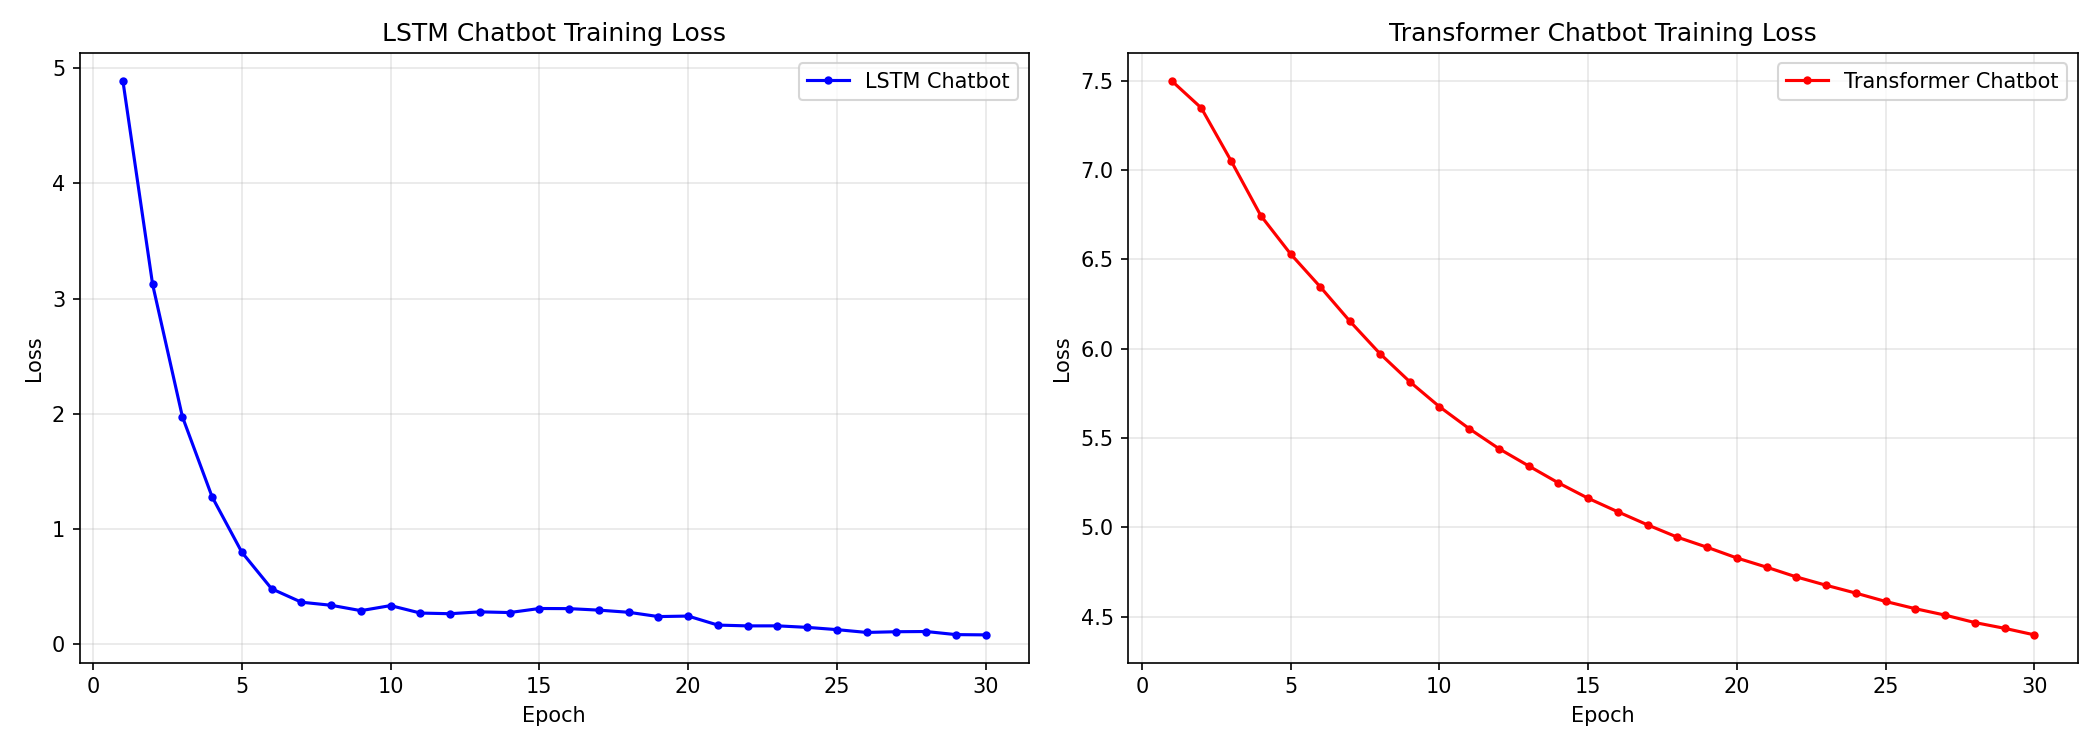

In [4]:
loss_plot = os.path.join(PROJECT_ROOT, "task2_chatbot", "chatbot_loss_curves.png")

if os.path.exists(loss_plot):
    display(Image(filename=loss_plot))
else:
    print(f"(No chatbot_loss_curves.png found at {loss_plot}.)")

## Part 4 - Cross-cutting findings

### Modeling capacity vs. data

| Architecture | Training cost | Long-range context | Fits small data? |
|---|---|---|---|
| Markov chain | lowest (counting) | none beyond n-gram order | yes, trivially |
| RNN | medium | weak (vanishing gradients) | yes, but plateaus |
| LSTM (text gen) | medium | much better than RNN | yes, best under small data |
| LSTM seq2seq + attention | medium-high | good | yes, our strongest chatbot at this scale |
| Transformer | highest per epoch (but parallel) | best in principle | data-hungry — shows its edge mainly with more data |

### Character vs. word tokenization

- **Character-level** has a tiny vocab but needs to learn spelling *and* grammar from scratch. Great for capturing letter-level patterns; harder to form coherent words on a small corpus.
- **Word-level** starts from real words — output is always real English tokens — at the cost of a larger vocabulary and an out-of-vocabulary problem.

### Why the Transformer doesn't dominate here

Transformers win decisively at scale. With only ~2k QA pairs and no pretrained embeddings, they're undertrained: attention needs many examples to learn useful patterns, and positional encodings add capacity that small data can't fill. The LSTM seq2seq is a stronger baseline in this regime because its inductive bias (sequential, gated memory) transfers more signal per example.

### What would move the needle

- **More data** (or augmentation) — the single biggest lever.
- **Pretrained token embeddings** (GloVe / fastText) before training either chatbot.
- **Byte-pair encoding (BPE)** to get the tokenization sweet spot between char and word.
- **Beam search or sampling** instead of greedy decoding at inference time.
- **Validation split + early stopping** — current setup doesn't hold out data.

## Part 5 - Final summary

**Task 1 — text generation (6 models).** Markov chains are the fastest but produce locally plausible, globally incoherent text. Among neural models, LSTMs consistently outperform RNNs at equal parameter budget; at the character level this difference is largest because longer context matters more when each token carries less information.

**Task 2 — chatbots (2 models).** Both the LSTM seq2seq with Bahdanau attention and the from-scratch Transformer learn to map templated QA pairs. In this small-data regime the LSTM typically matches or slightly outperforms the Transformer; with more data and/or pretrained embeddings the ordering would flip.

**Meta note.** Everything — tokenizers, datasets, attention mechanisms, positional encoding, the full Transformer — was implemented from scratch in PyTorch with no pretrained weights, which makes this pipeline a compact didactic tour through the last 15 years of sequence modeling.